# Gas Source Estimation with Unknown Wind

This example jointly estimates concentration, source, and wind from sparse gas
and wind measurements:

$$
C_\phi:(x,y)\mapsto c_\phi(x,y)\geq0,
\qquad
Q_\psi:(x,y)\mapsto q_\psi(x,y)\geq0.
$$

The wind component is interchangeable:

1. **Navier–Stokes:**
   $W_\theta:(x,y)\mapsto(u_\theta,v_\theta,p_\theta)$, constrained by
   incompressibility and stationary momentum balance.
2. **Streamfunction:**
   $S_\theta:(x,y)\mapsto\Psi_\theta$, with
   $u_\theta=\partial_y\Psi_\theta$ and
   $v_\theta=-\partial_x\Psi_\theta$. Incompressibility then holds exactly and
   no pressure field or momentum residual is used.

Both formulations are coupled to concentration and source through

$$
-D\Delta c_\phi
+\mathbf u_\theta\cdot\nabla c_\phi
-q_\psi=0.
$$

All active network parameters are optimized jointly. Changing the wind
formulation therefore replaces only the wind model and its prior, not the gas
model, source model, or their advection–diffusion coupling.


In [93]:
%cd /app

import matplotlib.pyplot as plt
import numpy as np
import torch

from source_estimation_pinn.environment import OccupancyGrid
from source_estimation_pinn.estimation.estimator import (
    #NavierStokesWindConfig,
    StreamFunctionWindConfig,
    WindGasSourceConfig,
    WindGasSourceEstimator,
)
from source_estimation_pinn.measurements import GasSampleSet, WindSampleSet

# Synthetic example data
case_dir = "data/example_labyrinth"
true_source = np.array([1.5, 2.0])  # evaluation only, not used for training

torch.manual_seed(12)
occupancy = OccupancyGrid.from_msh_file(
    f"{case_dir}/labyrinth_2d_fine.msh", resolution=0.1
)
gas_samples = GasSampleSet.from_csv(
    f"{case_dir}/gas_gt1.5_2.0.csv", n=50, random_seed=123
)
wind_samples = WindSampleSet.from_csv(
    f"{case_dir}/wind_gt.csv", n=50, random_seed=128
)


/app



## Information and constraints used during training

The estimate combines gas measurements, wind measurements, the
advection–diffusion equation, source priors, and boundary information derived
from the occupancy grid.

The selected wind component contributes either:

- Navier–Stokes momentum, soft divergence, pressure gauge, and no-slip losses; or
- streamfunction smoothness and wall-impermeability losses, with divergence-free
  velocity guaranteed by construction.

Gas uses zero normal flux at solid walls and zero concentration at open-boundary
points currently classified as inflow. The source remains positive, sparse, and
suppressed outside free space.

The shared objective is

$$
\mathcal L =
\mathcal L_\mathrm{gas}
+\mathcal L_\mathrm{AD}
+\mathcal L_\mathrm{source}
+\mathcal L_\mathrm{selected\ wind}.
$$

A single Adam optimizer updates every active network jointly; separate learning
rates are only optimizer parameter-group settings.


In [94]:
# Select exactly one interchangeable wind formulation.
wind_config = StreamFunctionWindConfig(
    hidden_layers=3,
    hidden_dim=64,
    lambda_data=1.0,
    lambda_smooth=1e-3,
    lambda_wall=1e0,
    learning_rate=1e-3,
)

# For a Navier–Stokes wind prior, replace the block above with:
# wind_config = NavierStokesWindConfig(
#     hidden_layers=3,
#     hidden_dim=32,
#     lambda_data=1.0,
#     lambda_smooth=0.01,
#     lambda_div=1.0,
#     lambda_momentum=1.0,
#     lambda_pressure=0.0,
#     lambda_wall=1.0,
#     kinematic_viscosity=1e-5,
#     learning_rate=1e-3,
# )

config = WindGasSourceConfig(
    concentration_hidden_layers=3,
    concentration_hidden_dim=64,
    source_hidden_layers=3,
    source_hidden_dim=32,
    diffusion_constant=1e-3,
    lambda_sparse=0.0,
    lambda_nonfree=1e-1,
    learning_rate=2e-3,
    wind=wind_config,
)

estimator = WindGasSourceEstimator(occupancy=occupancy, config=config)
history = estimator.fit(
    gas_samples,
    wind_samples,
    steps=1000,
    n_collocation_points=len(occupancy.free_points) // 4,
)


Estimated source: [1.45 2.15]
Distance to truth: 0.15811388300841883


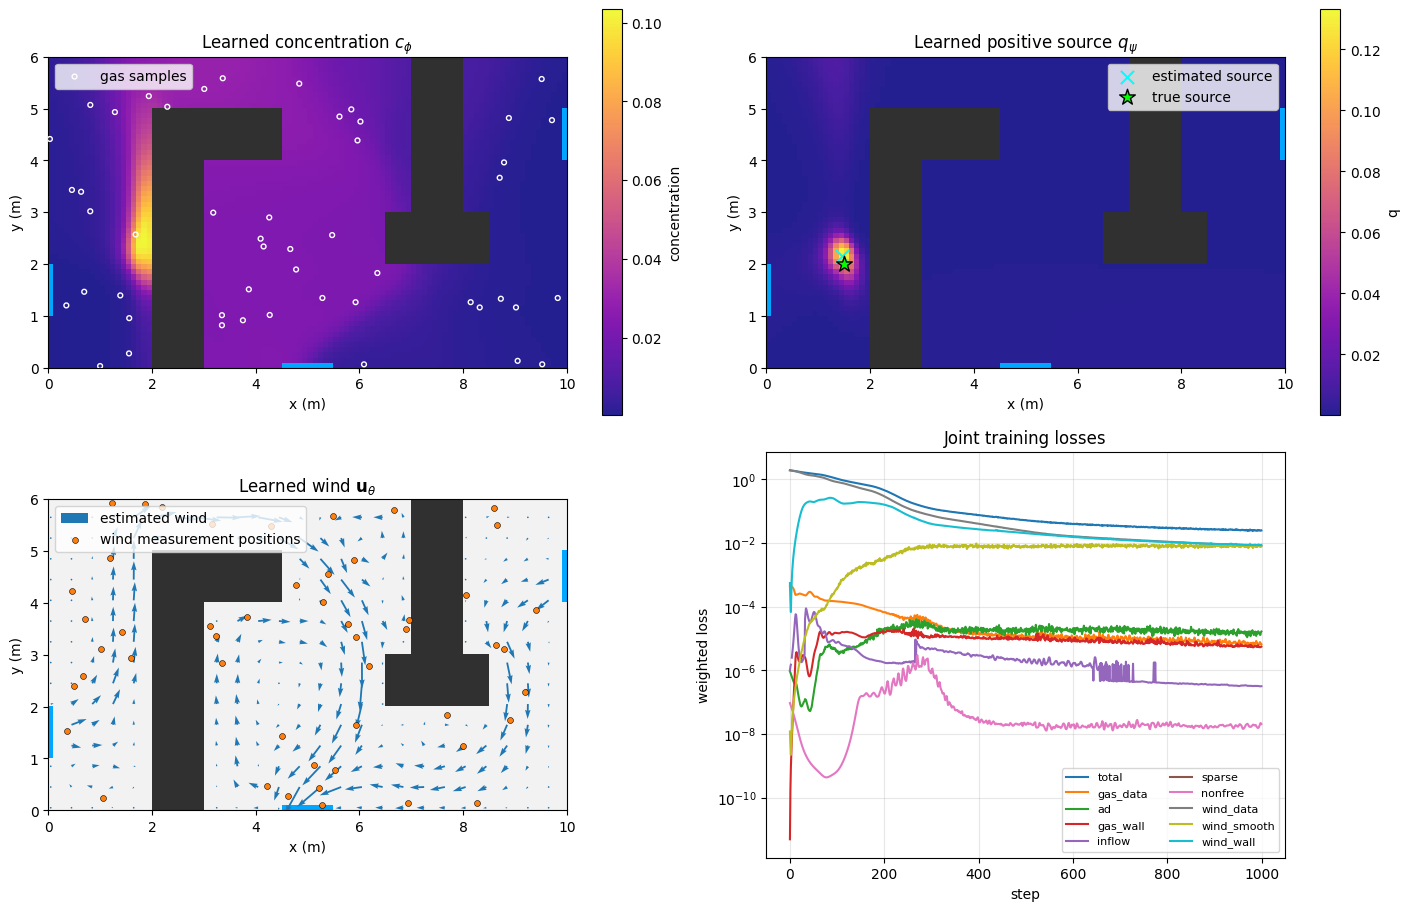

In [95]:
# Evaluate concentration, source, and wind on the free grid cells.
free_points = occupancy.free_points
c_free = estimator.predict_concentration(free_points)
q_free = estimator.predict_source(free_points)
uv_free = estimator.predict_wind(free_points)
source_estimate = estimator.get_source_estimate()

fields = []
for prediction in (c_free, q_free):
    field = np.full(occupancy.occupancy.shape, np.nan)
    field[occupancy.free_mask] = prediction
    fields.append(field)

extent = [
    occupancy.lower_bound[0], occupancy.upper_bound[0],
    occupancy.lower_bound[1], occupancy.upper_bound[1],
]
fig, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)

for ax, field, title, label in zip(
    axes[0],
    fields,
    (r"Learned concentration $c_\phi$", r"Learned positive source $q_\psi$"),
    ("concentration", "q"),
):
    occupancy.plot(ax=ax, title=title)
    ax.get_legend().remove()
    image = ax.imshow(
        field, origin="lower", extent=extent, cmap="plasma",
        interpolation="nearest", alpha=0.9, zorder=2,
    )
    fig.colorbar(image, ax=ax, label=label)

axes[0, 0].scatter(
    *gas_samples.positions.T, s=12, facecolors="none", edgecolors="white",
    label="gas samples", zorder=4,
)
axes[0, 0].legend()
axes[0, 1].scatter(
    *source_estimate, marker="x", s=90, color="cyan",
    label="estimated source", zorder=5,
)
axes[0, 1].scatter(
    *true_source, marker="*", s=140, color="lime", edgecolor="black",
    label="true source", zorder=5,
)
axes[0, 1].legend()

# Use a regular 2D subgrid; slicing flattened points would create stripes.
rows, columns = np.indices(occupancy.free_mask.shape)
plot_mask = (
    occupancy.free_mask
    & (rows % 4 == 0)
    & (columns % 4 == 0)
)
xx, yy = np.meshgrid(occupancy.x_centers, occupancy.y_centers)
wind_plot_points = np.column_stack((xx[plot_mask], yy[plot_mask]))
uv_plot = estimator.predict_wind(wind_plot_points)

ax = axes[1, 0]
occupancy.plot(ax=ax, title=r"Learned wind $\mathbf{u}_\theta$")
ax.get_legend().remove()
quiver_options = dict(angles="xy", scale_units="xy", scale=6.0, zorder=3)
ax.quiver(
    wind_plot_points[:, 0], wind_plot_points[:, 1],
    uv_plot[:, 0], uv_plot[:, 1],
    color="tab:blue", label="estimated wind", **quiver_options,
)
ax.scatter(
    wind_samples.positions[:, 0], wind_samples.positions[:, 1],
    s=18, color="tab:orange", edgecolor="black", linewidth=0.4,
    label="wind measurement positions", zorder=4,
)
ax.legend()

ax = axes[1, 1]
for name, values in history.losses.items():
    values = np.asarray(values)
    ax.semilogy(np.where(values > 0, values, np.nan), label=name)
ax.set(title="Joint training losses", xlabel="step", ylabel="weighted loss")
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=8, ncol=2)

print("Estimated source:", source_estimate)
print("Distance to truth:", np.linalg.norm(source_estimate - true_source))
plt.show()


## Concentration-field diagnostic

Reference values are mapped to free occupancy-cell centers using the nearest FEM point, avoiding interpolation triangles across obstacles. Reference and prediction share one color scale.

Full-field concentration RMSE: 7.768e-03
Nearest-reference distance: mean=2.731e-02 m, max=6.684e-02 m


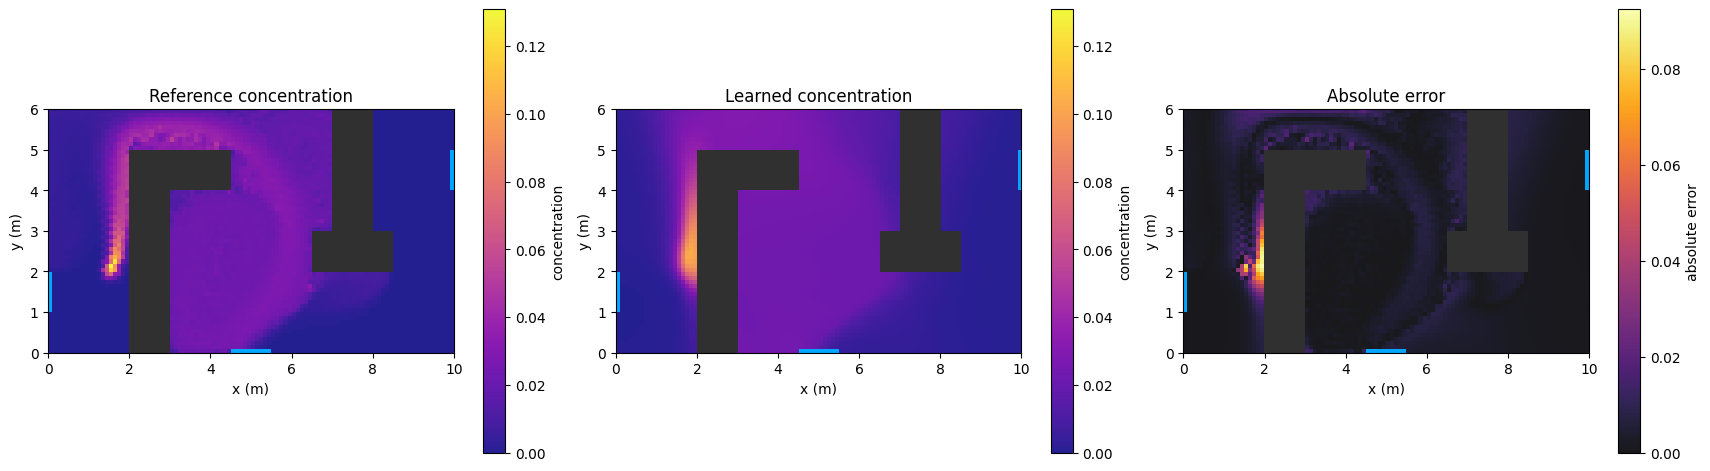

In [96]:
from scipy.spatial import cKDTree

reference_gas = GasSampleSet.from_csv(f"{case_dir}/gas_gt1.5_2.0.csv")
nearest_distance, nearest_index = cKDTree(reference_gas.positions).query(free_points)
c_true_free = reference_gas.concentrations[nearest_index]
c_error_free = np.abs(c_free - c_true_free)

def free_field(values):
    field = np.full(occupancy.occupancy.shape, np.nan)
    field[occupancy.free_mask] = values
    return field

diagnostic_fields = (
    free_field(c_true_free), free_field(c_free), free_field(c_error_free)
)
concentration_max = max(np.nanmax(diagnostic_fields[0]), np.nanmax(diagnostic_fields[1]))
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6), constrained_layout=True)
for index, (ax, field, title) in enumerate(zip(
    axes, diagnostic_fields,
    ("Reference concentration", "Learned concentration", "Absolute error"),
)):
    occupancy.plot(ax=ax, title=title)
    if ax.get_legend() is not None:
        ax.get_legend().remove()
    image = ax.imshow(
        field, origin="lower", extent=extent,
        cmap="inferno" if index == 2 else "plasma", vmin=0.0,
        vmax=None if index == 2 else concentration_max,
        interpolation="nearest", alpha=0.9, zorder=2,
    )
    fig.colorbar(image, ax=ax, label="absolute error" if index == 2 else "concentration")

print(f"Full-field concentration RMSE: {np.sqrt(np.mean((c_free-c_true_free)**2)):.3e}")
print(f"Nearest-reference distance: mean={nearest_distance.mean():.3e} m, max={nearest_distance.max():.3e} m")
plt.show()